# Classification Capstone: Predicting Customer Purchasing Lapse
## Problem Framing

This project proposes predicting which recently active customers will place no valid merchandise order in the next 90 days. Its purpose is to help a retailer prioritize a limited, human-reviewed re-engagement campaign.

The framing below follows the supplied lecture notes and problem-framing assessment criteria. It defines the target, stakeholders, decision scenario, societal relevance, success criteria and boundaries. Numerical business targets are proposed assumptions, not achieved results or stakeholder-approved commitments.


# 1. Problem Definition & Context


## 1.1 Business problem and classification question

A retailer cannot give every customer the same amount of retention attention. Contacting everyone can waste staff time, offer unnecessary discounts and send unwanted messages. The CRM team needs a practical way to identify customers whose purchasing activity may be weakening.

> **At the start of each month, predict whether a customer who ordered in the previous 180 days will place no valid merchandise order in the next 90 days, using only information recorded before that date, so that the CRM team can prioritize customers for a limited re-engagement campaign.**

This follows the lecture's **five-part specification**:

| Part | Project definition |
|---|---|
| Decision | Which customers should the CRM team review for re-engagement? |
| Unit | One customer at one monthly prediction date |
| Event | No valid merchandise order during the following 90 days |
| Horizon | 90 days |
| Evidence | Customer purchase history available before the prediction date |

The proposed evidence is **UCI Online Retail II**, using both annual worksheets. It contains dated invoice lines, customer identifiers, products, quantities, prices and countries. These records can support customer-level histories and future purchase labels. The source is a UK-based online retailer with many wholesale customers; results cannot automatically be generalized to all retailers. [Dataset source and attribution: Chen, D. (2012), Online Retail II](https://doi.org/10.24432/C5CG6D).

A **valid merchandise order** must contain at least one genuine product line with a known customer, valid timestamp, positive quantity and positive price. Cancelled and adjustment invoices, exact duplicate lines, postage, fees, manual entries, discounts, vouchers and test records are excluded. Unusual product codes require review. Multiple product lines do not turn one invoice into several orders, and a postage-only invoice cannot establish a return purchase. The same rules apply to history and future outcomes. A later return does not retroactively change what was known at prediction time.

This is **binary classification**, because every eligible, fully observed customer has one of two outcomes. It is not regression: the target is a category, not the amount a customer will spend.


## 1.2 Target and eligible customers

The target is **lapse_90d**:

| Class | Definition | Decision meaning |
|---|---|---|
| **1 — Purchasing lapse** | No valid merchandise order in the next 90 days | Positive class: consider for re-engagement |
| **0 — Return purchase** | At least one valid merchandise order in the next 90 days | Lower priority for this campaign |

A customer is eligible if their Customer ID is known and they placed at least one valid order during the **180 days before the prediction date**. A customer with only one previous order can still qualify. Customers with no identifiable history, or no order in that window, are outside this project's population.

For prediction date the prediction date, use:

- **Eligibility and main feature window:** from 180 days before the prediction date up to, but not including, that date.
- **Outcome window:** from the prediction date up to, but not including, 90 days later.
- **Complete observation:** use a labelled example only when the entire outcome window is available.

An order exactly at the prediction date belongs to the outcome window. An order exactly at 90 days after the prediction date does not. An incomplete future window is **unlabelled**, not class 1. Each customer and prediction-date combination must occur once with exactly one label.

“Purchasing lapse” means no observed qualifying order at this retailer during the chosen period. It does **not** prove permanent churn, dissatisfaction or that a customer will respond to marketing.


In [1]:
# Five-part problem specification, adapted from the lecture notebook.
problem_spec = {
    "decision": "prioritize customers for human-reviewed re-engagement",
    "unit": "customer at a monthly prediction date",
    "event": "no valid merchandise order in the next 90 days",
    "horizon_days": 90,
    "prediction_time": "00:00 on the first day of each month",
    "evidence": "purchase history recorded before the prediction date",
    "eligibility": "at least one valid order in the previous 180 days",
    "target": "lapse_90d",
    "positive_class": "1 = purchasing lapse; 0 = return purchase",
}

for item, definition in problem_spec.items():
    print(f"{item}: {definition}")


decision: prioritize customers for human-reviewed re-engagement
unit: customer at a monthly prediction date
event: no valid merchandise order in the next 90 days
horizon_days: 90
prediction_time: 00:00 on the first day of each month
evidence: purchase history recorded before the prediction date
eligibility: at least one valid order in the previous 180 days
target: lapse_90d
positive_class: 1 = purchasing lapse; 0 = return purchase


## 1.3 Why this target fits the action

**Why 90 days?** A 30-day window can flag healthy customers who normally order every six to eight weeks. A 90-day window better fits a quarterly re-engagement objective and gives the team time to act. Some seasonal buyers will still be labelled as lapses, so the label should not be described as permanent churn.

**Why require activity within 180 days?** Including everyone who ever purchased would add long-inactive customers who are easy to classify but less useful for retention. The activity rule reduces that problem while keeping less frequent buyers. Customers last active 91–180 days ago still qualify, so later evaluation should compare performance across recency bands.

**Why use both worksheets?** The additional history supports a 180-day lookback, a full 90-day outcome window and later-time evaluation. It also provides some previous autumn behaviour before an autumn test. Two years remain a limited basis for generalizing across seasons.

The supplied feedback reports that approximately 83% of completed purchase gaps were 90 days or less. This is **preliminary supporting evidence from the feedback**, not a result reproduced here. Completed gaps describe customers who returned and omit customers who never returned; they cannot by themselves establish the best horizon.


## 1.4 Prediction timeline and leakage prevention

**Past 180 days:** determine eligibility and summarize purchase history.

**Prediction date:** estimate lapse risk and prepare the review shortlist.

**Following 90 days:** observe whether a qualifying purchase occurs and assign the outcome.

For example, a prediction on **1 June 2011** uses the main historical window from **3 December 2010 up to, but not including, 1 June 2011**. Its outcome window ends on **30 August 2011 at 00:00**, exclusive.

Features must use only information available before the prediction date. Future purchases and future returns cannot become inputs. The source timestamps do not establish when records reached the retailer's systems; timely availability is an offline assumption that must be checked before live use.


## 1.5 Hypothesis and candidate features

**Hypothesis:** past purchase frequency, spending and basket behaviour can identify purchasing lapses more accurately than using only days since the last order.

The meaningful comparison is therefore a **recency rule**: the longer since the last order, the higher the estimated risk. If a model does not improve on that rule, the extra complexity is not justified.

| Feature | Simple definition before prediction | Reason for considering it |
|---|---|---|
| Recency | Days since the most recent valid order | Measures current inactivity |
| Frequency | Distinct invoices in the last 30, 90 and 180 days | Describes purchasing regularity |
| Spending | Total quantity multiplied by price in the last 90 and 180 days | Measures recent purchasing activity |
| Average order value | Historical spending divided by order count | Describes typical basket value |
| Product diversity | Distinct merchandise StockCode values in 180 days | Describes breadth of purchasing |
| Observed tenure | Days since the first purchase seen before prediction | Helps distinguish short and long observed histories |

Spending is positive merchandise purchase value, not profit or net revenue after returns. Observed tenure is not necessarily the true relationship age because records start partway through the retailer's history.

Customer ID and Invoice are grouping keys, not model features. Product descriptions will not be one-hot encoded. Country will initially be used for fairness checks rather than prediction. Historical return features can be considered later if their timing and definitions are reliable.

These are **predictive associations**. They do not show that changing a feature, or contacting a customer, will prevent a lapse.


## 1.6 Stakeholders and a concrete decision scenario

On each monthly prediction date, the CRM team receives a ranked list and reviews at most the **highest-risk 20%** of eligible customers. The 20% limit is a proposed capacity assumption, to be confirmed with the business.

**Example:** if 3,000 customers qualify, up to 600 enter review. Staff check contact permission, previous campaign contact and unresolved service issues. They may send a relevant service check-in, postpone contact or remove the customer from the campaign. A high score does not automatically authorize an offer.

The proposed contact limit is **one campaign contact per customer per 90 days**. Customers outside the shortlist retain normal service. The model must not automatically change prices, deny service or send repeated promotions. Consent and contact-history information are not in this dataset, so the analytical shortlist is not an approved contact list.

| Stakeholder | Expected benefit | Main concern | Responsibility |
|---|---|---|---|
| CRM team | More focused use of limited time | Over-reliance on scores | Review the shortlist and contact rules |
| Customers | More relevant support and fewer blanket promotions | Unwanted contact or pressure | Preferences and opt-outs must be respected |
| Retailer | More efficient retention spending | Wasted offers or missed opportunities | Set capacity, costs and pilot limits |
| Data analyst | A clear, reproducible decision process | Leakage or misleading performance | Check data, errors and model limitations |


## 1.7 Societal relevance and impact

The potential social value is a more responsible relationship between the retailer and its customers: limited, relevant support instead of repeated mass promotions. Where wholesale customers are small businesses, a reliable supplier relationship may also support continuity of their operations.

This offers a plausible link to **SDG 8**, particularly support for entrepreneurship and small-business growth. However, the dataset identifies neither business size nor employment outcomes. It would be incorrect to claim that all wholesale customers are SMEs or that this model creates jobs.

The impact should be tested through **incremental 90-day contribution margin per £ of campaign spend**, compared with a randomized no-contact control. Contribution margin means revenue less variable product costs; campaign costs must also be recorded. Complaint and opt-out rates should be monitored alongside economic outcomes. These measures are not available in the supplied transactions and must be collected during a future pilot.

No environmental benefit is claimed. Additional purchases can increase deliveries and consumption, and the data contain no emissions or waste measurements.

### Benefit and harm quadrant from the lecture

| | Direct effect | Indirect effect |
|---|---|---|
| **Benefit** | Customers receive relevant support; CRM uses time more efficiently | Potentially more stable supplier relationships for wholesale businesses |
| **Harm** | Customers receive unnecessary contact; retailer wastes discounts | Infrequent or overseas customers receive unequal attention; increased consumption |

### Initial risk scoring

Following the lecture, **risk = severity × likelihood**, with both scored from 1 to 5. These are planning judgments, not measured probabilities. Risks scoring 15 or more require mitigation before a pilot.

| Potential harm | Severity | Likelihood | Risk score | Mitigation and owner |
|---|---:|---:|---:|---|
| Repeated unwanted contact | 4 | 4 | 16 | CRM lead: check permission and enforce the 90-day contact limit |
| Unequal targeting of customer groups | 4 | 3 | 12 | Analyst: compare group errors and selection rates; maintain normal service for all customers |
| Disclosure or linkage of purchase histories | 5 | 3 | 15 | Data owner: restrict access, prevent re-identification and publish aggregate results |


## 1.8 Success metrics and error costs

All precision, recall and F1 measures refer to **class 1: purchasing lapse**.

| Measure | Proposed success criterion | Decision connection |
|---|---|---|
| **Average precision (AP)** | At least **0.05 absolute improvement** over the recency rule on validation | The model should rank lapsing customers better than a simple rule |
| **Precision at the top 20%** | At least **0.05 absolute improvement** over recency at the same capacity | A fixed review workload should identify more actual lapses |
| Final test | Freeze all choices and check the same improvements on the later test | Establish whether the improvement carries forward in time |
| Pilot impact | Incremental contribution margin / campaign spend **greater than 1** | Additional contribution should exceed campaign cost |
| Customer treatment | No unauthorized contact or contact-limit breaches; complaint increase no more than **0.5 percentage points** versus control | Benefits must not depend on intrusive treatment |

These numbers are **proposed targets**, not achieved results or stakeholder-approved budgets. If they are missed, report the failure and reconsider whether the model is useful.

AP summarizes the precision–recall curve across score thresholds; it will be calculated with the standard average-precision calculation. It is not the same calculation as trapezoidal PR-AUC. Precision at the top 20% is the proportion of the shortlisted customers who actually lapse. Also report recall at that capacity, a confusion matrix, class-1 F1 and ROC-AUC. If scores are presented as probabilities, check calibration and Brier score.

| Error | What happens | Illustrative cost |
|---|---|---|
| False positive | Customer is flagged but would return; contact or discount may be unnecessary | £2 |
| False negative | Customer lapses without entering the shortlist; a support opportunity may be missed | £10 |

Under these assumptions, a false negative costs five times as much as a false positive. The average error penalty is **(£2 × false positives + £10 × false negatives) ÷ number of customers**. These are illustrative penalties, not measured losses: a missed lapse may not have been preventable. Repeat the analysis with equal costs and with a 10:1 ratio. Actual campaign economics must include the cost of every contact, including correct flags.

Start with the top-20% capacity rule, resolving tied scores reproducibly without using labels. If a probability threshold is used, select it on validation under the capacity limit and freeze it before testing; do not assume 0.5 is best. A high lapse probability does not imply a high probability of responding to an offer.


## 1.9 Validation plan

| Split | Monthly prediction dates | Latest outcome window ends |
|---|---|---|
| Training | June 2010 to March 2011 | 30 May 2011 |
| Validation | 1 June 2011 | 30 August 2011 |
| Test | 1 September 2011 | 30 November 2011 |

Use both sheets, subject to confirming these windows are fully covered. **Every training label must be known before the next evaluation date:** the training outcome window must end on or before the evaluation date. April and May 2011 training snapshots would violate this rule for June validation and must be excluded.

During training, use earlier expanding-time checks, for example December 2010 and March 2011, applying the same rule. Learn scaling, imputation and model settings from each training fold only. Use June validation to finalize the model and shortlist policy, then keep the fitted model fixed for the September test.

The capstone recommends stratification, but a random stratified split would mix past and future customer snapshots here. **Time-based evaluation is the justified primary choice.** Check class support in each split while preserving its natural prevalence. A customer-group split alone would also fail to preserve time order. A separate unseen-customer assessment could provide a secondary check.

The same customer can appear at multiple dates because the intended use is repeated scoring of existing customers. Those rows are not independent. Later uncertainty estimates should resample whole customers rather than individual rows. Report performance across time as well: one autumn test cannot establish year-round reliability.


## 1.10 Ethics and boundaries

The main concern is turning a prediction into repeated marketing pressure. Human review, permission checks and contact limits are therefore part of the decision design.

The data come from one retailer and an older period. Missing customer IDs exclude some purchases and may make the eligible population unrepresentative. Geography and purchasing patterns may also reflect unequal circumstances. Removing Country from model inputs does not remove all proxy bias.

Later checks should compare selection rates and errors for UK/non-UK customers, one-order/repeat-order customers and recency bands of 0–30, over 30–90 and over 90–180 days. Report group sizes; avoid firm conclusions for small groups. Missing demographic attributes mean demographic fairness cannot be established. Do not infer sensitive attributes or attempt re-identification.

The expected use is ordinary retail decision support and is provisionally considered lower-risk for project planning. This is not a formal legal classification. Any live deployment needs a review of applicable privacy and marketing rules. Public dataset availability is not marketing consent.

**In scope:** predicting a 90-day purchasing lapse for recently active customers. **Out of scope:** permanent churn, campaign uplift, product recommendations, automated contact, price discrimination and environmental-impact claims.


---
# 2. Dataset Selection & Description


## 2.1 Import Libraries

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

## 2.2 Data Loading and Initial Understanding

The Online Retail II dataset is provided in two Excel worksheets covering consecutive periods: **2009–2010** and **2010–2011**. Both worksheets are loaded separately and concatenated into a single DataFrame to create a continuous transaction-level dataset for subsequent analysis.

Each row represents an individual product line within a customer invoice rather than a complete customer or order. Therefore, customer-level features and the final classification target will need to be constructed later by aggregating these transaction records over appropriate time windows.

In [3]:
# Load datasets
df1 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name="Year 2009-2010")
df2 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name="Year 2010-2011")

df = pd.concat([df1, df2], ignore_index=True)
display(df.shape)
df.head()

(1067371, 8)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Initial Dataset Overview

After combining the two worksheets, the dataset contains **1,067,371 transaction rows and 8 variables**.

The available variables describe invoice information, products, transaction quantities and prices, customer identifiers, transaction dates, and customer countries. The first observations confirm that the data is currently organised at the **invoice-product transaction level**.

The dataset covers transactions from **1 December 2009 to 9 December 2011**, providing approximately two years of purchasing history. This longitudinal structure is suitable for constructing historical customer behaviour features and future lapse outcomes using time-based prediction windows.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,1.067371e+06,1067371,1.067371e+06,824364.000000
mean,9.938898e+00,2011-01-02 21:13:55.394029,4.649388e+00,15324.638504
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000
std,1.727058e+02,NaN,1.235531e+02,1697.464450


### Initial Observations

The initial inspection highlights several characteristics that require further investigation before modelling:

- **Quantity** contains both positive and negative values, ranging from **-80,995 to 80,995**. Negative quantities may represent cancellations or returned products rather than ordinary purchases.
- **Price** also contains unusual values, including negative values and very large positive values. These records require investigation before deciding whether they represent valid transactions, adjustments, or data-quality issues.
- **Customer ID** is not available for every transaction, which is particularly important because the classification problem is defined at the customer level.
- The large ranges observed for Quantity and Price suggest that their distributions may be highly skewed and contain extreme observations.
- `InvoiceDate` is already stored as a datetime variable, which will support chronological splitting and construction of observation and outcome windows.

These observations are treated as issues for further investigation rather than immediately removing records, since unusual transaction values may have a legitimate business meaning.

### Understanding Data Types

The variables are reviewed by both their stored data type and their analytical
role. This distinction is important because a variable may be stored as numeric
without representing a continuous numerical feature. For example, `Customer ID`
is stored numerically but functions as an identifier rather than a quantitative
measurement.

Automatic type detection is therefore used as an initial diagnostic and will be
combined with domain understanding before preprocessing decisions are made.

In [6]:
def detect_variable_types(df, target_col=None):
    """Automatically detect variable types in a DataFrame"""
    types = {}
    
    for col in df.columns:
        if col == target_col:
            types[col] = 'target'
        elif pd.api.types.is_datetime64_any_dtype(df[col]):
            types[col] = 'datetime'
        elif pd.api.types.is_numeric_dtype(df[col]):
            if df[col].nunique() == 2:
                types[col] = 'binary'
            else:
                types[col] = 'numerical'
        elif df[col].nunique() < 20:  # Threshold for categorical
            types[col] = 'categorical'
        elif df[col].dtype == 'object':
            # Check if it's text (long strings) or categorical
            avg_length = df[col].astype(str).str.len().mean()
            if avg_length > 50:
                types[col] = 'text'
            else:
                types[col] = 'categorical'
    
    return types

detect_variable_types(df)

{'Invoice': 'categorical',
 'StockCode': 'categorical',
 'Description': 'categorical',
 'Quantity': 'numerical',
 'InvoiceDate': 'datetime',
 'Price': 'numerical',
 'Customer ID': 'numerical'}

### Data Quality Assessment

The initial data-quality assessment examines missing values, exact duplicate
records, zero values, numerical ranges, and transaction values that may violate
expected business rules.

At this stage, the purpose is diagnostic rather than corrective. Records are
flagged for investigation first, and cleaning decisions are made only after
considering their possible business meaning and their relevance to the
customer-level prediction problem.

In [7]:
# Basic missing value overview
def quick_missing_analysis(df):
    missing_counts = df.isnull().sum()
    missing_percent = (missing_counts / len(df)) * 100
    
    print("Missing Value Summary:")
    for col in df.columns:
        if missing_counts[col] > 0:
            print(f"  {col}: {missing_counts[col]} missing ({missing_percent[col]:.1f}%)")

quick_missing_analysis(df)

Missing Value Summary:
  Description: 4382 missing (0.4%)
  Customer ID: 243007 missing (22.8%)


#### Missing Values

Missingness is concentrated in two variables:

- `Description`: **4,382 missing records (0.4%)**
- `Customer ID`: **243,007 missing records (22.8%)**

Missing product descriptions affect only a small proportion of the data.
Missing customer identifiers are substantially more important because
customer-level purchase histories and lapse labels cannot be constructed
reliably for transactions without an identifiable customer.

The treatment of these records will therefore be addressed during the cleaning
stage rather than applying automatic imputation.

In [8]:
# Check duplicates
duplicates = df.duplicated().sum()
duplicates_percentage = (duplicates/len(df))*100
print(f"Exact duplicates: {duplicates} ({duplicates_percentage:.2f})%")

Exact duplicates: 34335 (3.22)%


#### Duplicate Records

The dataset contains **34,335 exact duplicate rows**, representing approximately
**3.22%** of all records.

Because these rows are exact duplicates, they may artificially inflate purchase
frequency, quantities, or customer spending if retained. Their treatment will
therefore be considered during the initial cleaning stage before customer-level
features are constructed.

In [9]:
# Check zero values in num_cols
def quick_zero_analysis(df):

  num_cols = df.select_dtypes(include=['number']).columns
  zero_analysis = []

  for col in num_cols:

    zero_analysis.append({
      'name': col,
      'zero_counts': len(df[df[col] == 0]),
      'zero_percentage': (len(df[df[col]==0])/len(df))*100
    })

  zero_df = pd.DataFrame(zero_analysis).round(2)

  return zero_df

quick_zero_analysis(df)

,name,zero_counts,zero_percentage
0,Quantity,0,0.00
1,Price,6202,0.58
2,Customer ID,0,0.00


In [10]:
# Range and distribution check
def basic_range_check(df):
    numeric_cols = df.select_dtypes(include=['number']).columns
    
    for col in numeric_cols:
        print(f"{col}: min={df[col].min()}, max={df[col].max()}")
        
        # Flag obviously problematic values
        if col.lower() in ['age'] and (df[col].min() < 0 or df[col].max() > 120):
            print(f"  Suspicious age values detected")
        elif col.lower() in ['salary', 'income', 'price'] and df[col].min() < 0:
            print(f"  Negative financial values detected")

basic_range_check(df)

Quantity: min=-80995, max=80995
Price: min=-53594.36, max=38970.0
  Negative financial values detected
Customer ID: min=12346.0, max=18287.0


In [11]:
# Domain-specific outlier detection
def check_business_rules(data):
    issues = []
    
    # Age should be reasonable
    if 'Quantity' in data.columns:
        bad_quantities = data[(data['Quantity'] < 0) | (data['Quantity'] > 120)]
        if len(bad_quantities) > 0:
            issues.append(f"Impossible quantities: {len(bad_quantities)} records")
    
    # Prices should be positive
    if 'Price' in data.columns:
        bad_prices = data[data['Price'] <= 0]
        if len(bad_prices) > 0:
            issues.append(f"Non-positive prices: {len(bad_prices)} records")
    
    return issues

check_business_rules(df)

['Impossible quantities: 31675 records', 'Non-positive prices: 6207 records']

#### Transaction Value Checks

The numerical checks identify several transaction patterns requiring further
investigation. Quantity contains negative values and substantial extreme values,
while Price includes zero, negative, and unusually large observations.

These values should not automatically be classified as outliers or errors.
In retail transaction data, negative quantities may correspond to product
returns or cancelled invoices, while unusual prices may include adjustments,
special transactions, or data-entry issues.

For this project, a **valid merchandise purchase** must therefore be explicitly
defined before cleaning. Transactions representing cancellations, returns,
adjustments, or other non-purchase activity should be distinguished from genuine
customer purchases before constructing behavioural features and the
`lapse_90d` target.

In [12]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [13]:
df['StockCode'].value_counts()

StockCode
85123A    5829
22423     4424
85099B    4216
21212     3318
20725     3259
          ... 
85049c       1
84971l       1
85034b       1
23609        1
23617        1
Name: count, Length: 5305, dtype: int64

# 3. Initial Cleaning & Target Creation


## 3.1 Initial cleaning

The initial cleaning stage removes records that cannot be used reliably for customer-level modelling while preserving transaction information that may have legitimate business meaning.

Two cleaning decisions are applied at this stage:

- **Exact duplicate rows are removed**, because retaining identical transaction records could artificially inflate quantities, spending, and purchase frequency.
- **Transactions without a `Customer ID` are removed**, because the prediction task is defined at the customer level. Without an identifiable customer, these transactions cannot be linked to purchasing history or to a future lapse outcome.

Other unusual values, such as negative quantities and cancellation invoices, are investigated separately rather than automatically removed.

In [14]:
def initial_cleaning (df):
  df = df.copy()

  # Remove duplicates
  df = df.drop_duplicates()

  # Remove transactions without customer identifiers
  df = df[df['Customer ID'].notna()]

  return df

In [15]:
df = initial_cleaning(df)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Post-Cleaning Validation

After applying the initial cleaning rules, the resulting dataset is checked again for missing values and exact duplicate records. This validation ensures that the intended cleaning operations were successfully applied before investigating other transaction-level anomalies.

In [16]:
# Check null values again
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [17]:
# Check duplicated rows again
df.duplicated().sum()

np.int64(0)

The validation confirms that the cleaned dataset contains **no missing values** in the remaining variables and **no exact duplicate rows**.

Removing records with missing `Customer ID` also eliminates the small number of missing product descriptions that were present in the original dataset. The remaining observations can therefore be linked to identifiable customers and used for subsequent customer-level analysis.

### Investigation of Negative Values

The initial assessment identified negative values in the numerical variables. Rather than treating these automatically as outliers, they are examined to determine whether they represent invalid data or legitimate transaction behaviour.

Negative prices and negative quantities are investigated separately because they may have different business interpretations.

In [18]:
# Check further about minus price rows
df[df['Price'] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


#### Negative Prices

After removing transactions without identifiable customers, no records with a negative `Price` remain in the dataset.

Therefore, no additional cleaning action is required for negative prices at this stage.

In [19]:
# Check further about minus quantity rows
df[df['Quantity'] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


#### Negative Quantities and Cancelled Transactions

Negative quantities remain in the cleaned dataset and require further investigation. In retail transaction data, a negative quantity may represent a cancellation, return, or reversal rather than an erroneous numerical value.

To determine whether this is the case, invoice numbers are examined because cancelled invoices in this dataset appear to use the prefix `C`. A temporary diagnostic variable is therefore created to compare cancellation status with the sign of `Quantity`. This variable is used only for investigation and is not yet introduced as a modelling feature.

In [20]:
# Create is_cancelled column
df_check = df.copy()
df_check["is_cancelled"] = df_check["Invoice"].astype(str).str.startswith("C")

# Check cancelled orders relationship with the minus quantities
pd.crosstab(
    df_check["is_cancelled"],
    df_check["Quantity"] < 0
)

Quantity,False,True
is_cancelled,,
False,779495,0
True,0,18390


#### Treatment of Cancelled Transactions

The cross-tabulation shows a complete relationship between cancellation invoices and negative quantities:

- All **18,390** transactions with negative quantities have invoice numbers beginning with `C`.
- No non-cancelled invoice contains a negative quantity.
- All transactions identified as cancellations contain negative quantities.

This indicates that negative quantities are not random data-quality errors. They represent valid cancellation or return activity recorded by the retailer.

These records are therefore **retained in the cleaned dataset**. Removing only the cancellation records would leave the corresponding original purchases in the transaction history and could overstate customer purchasing activity. Similarly, converting negative quantities to positive values would destroy their business meaning.

The appropriate effect of cancellations on customer-level measures such as purchase frequency, quantity, spending, and recency will therefore be determined later during feature engineering.

## 3.2 Target Creation

The classification target is created at the **customer–reference-date level** rather than at the individual transaction level.

For each monthly reference date, the model asks:

**Will an eligible customer place no valid merchandise order during the following 90 days?**

The target is defined as:

- `lapse_90d = 1`: the customer places no valid merchandise order during the following 90 days.
- `lapse_90d = 0`: the customer places at least one valid merchandise order during the following 90 days.

Only valid purchase transactions are used when determining customer activity. Transactions with non-positive quantities or prices and invoices beginning with `C` are excluded from target construction because they do not represent successful merchandise purchases.

In [21]:
print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

2009-12-01 07:45:00
2011-12-09 12:50:00


In [22]:
# Filter purchases
purchases = df[(df['Quantity'] > 0) & (df['Price'] > 0) & (~df['Invoice'].astype(str).str.startswith("C"))]

### Reference Dates and Prediction Windows

Predictions are generated on the **first day of each month** from June 2010 to September 2011.

For every reference date, two time windows are used:

- **History window:** the previous 180 days, used to determine whether a customer is eligible for prediction.
- **Outcome window:** the following 90 days, used only to determine the target label.

A customer is eligible if they placed at least one valid order during the 180-day history window.

Transactions from the future outcome window are used only for target creation and must not later be used as predictive features for that reference date. This separation is necessary to prevent target leakage.

In [23]:
def target_creation (df):
  
  reference_dates = pd.date_range("2010-06-01", "2011-09-01", freq="MS")

  snapshots = []

  for reference_date in reference_dates:

    history_start = reference_date - pd.Timedelta(days=180)
    outcome_end = reference_date + pd.Timedelta(days=90)

    history = purchases[(purchases['InvoiceDate'] > history_start) & (purchases['InvoiceDate'] <= reference_date)]
    future = purchases[(purchases['InvoiceDate'] >= reference_date) & (purchases['InvoiceDate'] < outcome_end)]

    eligible_customers = history['Customer ID'].unique()
    returned_customers = future['Customer ID'].unique()

    snap = pd.DataFrame({
      'customer_id': eligible_customers,
      'reference_date': reference_date
    })

    snap['lapse_90d'] = (~snap['customer_id'].isin(returned_customers)).astype(int)

    snapshots.append(snap)

  target_df = pd.concat(snapshots, ignore_index=True)
  return target_df

### Target Construction Logic

For each monthly reference date:

1. The previous 180 days of valid purchases are selected.
2. Customers with at least one purchase in this period are identified as eligible.
3. Purchases occurring during the following 90 days are examined.
4. Eligible customers appearing in this future period are classified as returning customers.
5. Eligible customers who do not appear in the future period receive `lapse_90d = 1`, while customers who purchase again receive `lapse_90d = 0`.

Because the same customer may be eligible at several monthly reference dates, a customer can appear multiple times in the final target dataset. Each row therefore represents a unique **customer–reference-date prediction instance**.

In [24]:
# Create target_df
target_df = target_creation(df)
display(target_df.shape)
target_df.head()

(48079, 3)

,customer_id,reference_date,lapse_90d
0,12779.0,2010-06-01,0
1,13611.0,2010-06-01,0
2,15255.0,2010-06-01,0
3,14771.0,2010-06-01,1
4,14838.0,2010-06-01,1


## 3.3 Create the Final Table

The transaction data must now be converted into customer-level predictors for each reference date. Features are calculated exclusively from the 180-day history window preceding that date, ensuring that future information used to define the target does not enter the predictors.

The initial behavioural features capture three key aspects of purchasing activity: **recency** (days since the most recent purchase), **frequency** (number of distinct orders), and **monetary value** (total spending during the 180-day window).

These features are merged with the target table using `customer_id` and `reference_date`, producing the modelling dataset in which each row represents one customer at one prediction point.

In [25]:
# Create the line_total
purchases['line_total'] = purchases['Quantity'] * purchases['Price']

In [26]:
# Create summarize_customer_history function
def summarize_customer_history(purchases, reference_dates):
    all_feats = []
    
    for t0 in reference_dates:
        history = purchases[
            (purchases["InvoiceDate"] >= t0 - pd.Timedelta(days=180)) &
            (purchases["InvoiceDate"] <  t0)
        ]
        g = history.groupby("Customer ID")

        feats = pd.DataFrame({
            "recency_days":   (t0 - g["InvoiceDate"].max()).dt.days,
            "frequency_180d": g["Invoice"].nunique(),
            "spend_180d":     g["line_total"].sum(),
            "unique_products": g['Description'].nunique(),
            "total_items_180d": g['Quantity'].sum(),
            "active_days_180d": g["InvoiceDate"].apply(lambda x: x.dt.date.nunique()),
            'country': g['Country'].last()
        }).reset_index()

        feats = feats.rename(columns={"Customer ID": "customer_id"})
        feats["reference_date"] = t0
        all_feats.append(feats)

    return pd.concat(all_feats, ignore_index=True)

In [27]:
reference_dates = target_df["reference_date"].unique()
features_df = summarize_customer_history(purchases, reference_dates)

model_df = target_df.merge(features_df, on=["customer_id", "reference_date"], how="left")
model_df.head()

,customer_id,reference_date,lapse_90d,recency_days,frequency_180d,spend_180d,unique_products,total_items_180d,active_days_180d,country
0,12779.0,2010-06-01,0,91,2,690.68,35,460,2,Poland
1,13611.0,2010-06-01,0,53,3,781.87,54,421,3,United Kingdom
2,15255.0,2010-06-01,0,179,1,260.44,13,176,1,United Kingdom
3,14771.0,2010-06-01,1,64,2,594.62,46,622,2,United Kingdom
4,14838.0,2010-06-01,1,179,1,119.10,4,18,1,United Kingdom


In [28]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48079 entries, 0 to 48078
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       48079 non-null  float64       
 1   reference_date    48079 non-null  datetime64[us]
 2   lapse_90d         48079 non-null  int64         
 3   recency_days      48079 non-null  int64         
 4   frequency_180d    48079 non-null  int64         
 5   spend_180d        48079 non-null  float64       
 6   unique_products   48079 non-null  int64         
 7   total_items_180d  48079 non-null  int64         
 8   active_days_180d  48079 non-null  int64         
 9   country           48079 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(6), str(1)
memory usage: 3.7 MB


In [29]:
model_df.describe()

,customer_id,reference_date,lapse_90d,recency_days,frequency_180d,spend_180d,unique_products,total_items_180d,active_days_180d
count,48079.000000,48079,48079.000000,48079.000000,48079.000000,48079.000000,48079.00000,48079.000000,48079.000000
mean,15319.609746,2011-01-15 10:15:02.265022,0.509370,64.720252,2.867031,1309.432346,45.70952,802.454356,2.560203
min,12346.000000,2010-06-01 00:00:00,0.000000,0.000000,1.000000,1.300000,1.00000,1.000000,1.000000
25%,13856.000000,2010-10-01 00:00:00,0.000000,21.000000,1.000000,264.150000,14.00000,129.000000,1.000000
50%,15296.000000,2011-01-01 00:00:00,1.000000,52.000000,2.000000,521.640000,29.00000,288.000000,2.000000
75%,16794.000000,2011-05-01 00:00:00,1.000000,103.000000,3.000000,1139.070000,57.00000,656.000000,3.000000
max,18287.000000,2011-09-01 00:00:00,1.000000,179.000000,124.000000,179248.380000,1323.00000,220600.000000,76.000000
std,1701.570734,NaN,0.499917,50.564722,4.370181,4689.533814,59.45542,3601.033874,3.274164


The final modelling table contains one row for each **customer–reference-date** observation, with customer behaviour represented by aggregated features and `lapse_90d` as the classification target.

This table is now suitable for exploratory feature analysis and chronological train, validation, and test splitting.

# 4. Splitting & EDA


## 4.1 Splitting

In [30]:
def create_splits(df, train_reference, val_reference, test_reference):
    """Create train/validation/test splits"""
    
    # Create train/validation/test splits
    train_data = df[df['reference_date'] <= train_reference]
    val_data = df[df['reference_date'] == val_reference]
    test_data = df[df['reference_date'] == test_reference]

    # Verify class distributions
    print("Class distributions:")
    print(f"Train: {train_data['lapse_90d'].value_counts(normalize=True)}")
    print(f"Val:   {val_data['lapse_90d'].value_counts(normalize=True)}")  
    print(f"Test:  {test_data['lapse_90d'].value_counts(normalize=True)}")
    
    return train_data, val_data, test_data

In [31]:
train_data, val_data, test_data = create_splits(model_df, '2011-03-01', '2011-06-01', '2011-09-01')

Class distributions:
Train: lapse_90d
1    0.522532
0    0.477468
Name: proportion, dtype: float64
Val:   lapse_90d
0    0.500564
1    0.499436
Name: proportion, dtype: float64
Test:  lapse_90d
0    0.607143
1    0.392857
Name: proportion, dtype: float64


## 4.2 EDA on Train data

In [32]:
train_data.head()

,customer_id,reference_date,lapse_90d,recency_days,frequency_180d,spend_180d,unique_products,total_items_180d,active_days_180d,country
0,12779.0,2010-06-01,0,91,2,690.68,35,460,2,Poland
1,13611.0,2010-06-01,0,53,3,781.87,54,421,3,United Kingdom
2,15255.0,2010-06-01,0,179,1,260.44,13,176,1,United Kingdom
3,14771.0,2010-06-01,1,64,2,594.62,46,622,2,United Kingdom
4,14838.0,2010-06-01,1,179,1,119.10,4,18,1,United Kingdom


In [33]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30800 entries, 0 to 30799
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   customer_id       30800 non-null  float64       
 1   reference_date    30800 non-null  datetime64[us]
 2   lapse_90d         30800 non-null  int64         
 3   recency_days      30800 non-null  int64         
 4   frequency_180d    30800 non-null  int64         
 5   spend_180d        30800 non-null  float64       
 6   unique_products   30800 non-null  int64         
 7   total_items_180d  30800 non-null  int64         
 8   active_days_180d  30800 non-null  int64         
 9   country           30800 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(6), str(1)
memory usage: 2.3 MB


In [34]:
train_data.describe()

,customer_id,reference_date,lapse_90d,recency_days,frequency_180d,spend_180d,unique_products,total_items_180d,active_days_180d
count,30800.000000,30800,30800.000000,30800.000000,30800.000000,30800.000000,30800.000000,30800.000000,30800.000000
mean,15328.658734,2010-10-24 00:00:00,0.522532,62.580130,2.922532,1337.844424,47.026331,841.813377,2.586948
min,12346.000000,2010-06-01 00:00:00,0.000000,0.000000,1.000000,1.300000,1.000000,1.000000,1.000000
25%,13871.000000,2010-08-01 00:00:00,0.000000,20.000000,1.000000,271.257500,14.000000,133.000000,1.000000
50%,15311.000000,2010-11-01 00:00:00,1.000000,51.000000,2.000000,539.840000,30.000000,296.000000,2.000000
75%,16799.000000,2011-01-01 00:00:00,1.000000,97.000000,3.000000,1166.732500,58.000000,681.000000,3.000000
max,18287.000000,2011-03-01 00:00:00,1.000000,179.000000,124.000000,179248.380000,1323.000000,220600.000000,76.000000
std,1694.155806,NaN,0.499500,48.718228,4.531970,4882.762379,61.165007,3995.029274,3.301653


In [35]:
# Check target column
train_data['lapse_90d'].value_counts()

lapse_90d
1    16094
0    14706
Name: count, dtype: int64

In [36]:
# Check types in train_data
detect_variable_types(train_data)

{'customer_id': 'numerical',
 'reference_date': 'datetime',
 'lapse_90d': 'binary',
 'recency_days': 'numerical',
 'frequency_180d': 'numerical',
 'spend_180d': 'numerical',
 'unique_products': 'numerical',
 'total_items_180d': 'numerical',
 'active_days_180d': 'numerical'}

In [46]:
# outlier detection
num_cols = ['recency_days', 'frequency_180d', 'spend_180d', 'unique_products', 'total_items_180d', 'active_days_180d']

def find_iqr_outliers(data, cols):
    results = []

    for col in cols:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = data[
            (data[col] < lower) |
            (data[col] > upper)
        ]

        results.append({
            'feature': col,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': len(outliers),
            'outlier_percentage': len(outliers) / len(data) * 100
        })
    display(outliers)
    return pd.DataFrame(results)

find_iqr_outliers(train_data, num_cols)

,customer_id,reference_date,lapse_90d,recency_days,frequency_180d,spend_180d,unique_products,total_items_180d,active_days_180d,country
13,12921.0,2010-06-01,0,7,13,8319.86,120,5449,12,United Kingdom
18,15291.0,2010-06-01,0,21,16,5432.01,51,1263,15,United Kingdom
29,15768.0,2010-06-01,0,4,24,12057.77,418,3385,23,United Kingdom
30,12835.0,2010-06-01,0,3,28,4466.02,137,1666,25,United Kingdom
31,15061.0,2010-06-01,0,3,28,27259.34,62,16126,20,United Kingdom
...,...,...,...,...,...,...,...,...,...,...
29516,17690.0,2011-03-01,0,42,8,3042.28,118,1166,7,United Kingdom
29559,18061.0,2011-03-01,0,6,7,1576.08,11,932,7,United Kingdom
29656,14733.0,2011-03-01,0,18,9,11689.96,127,4844,9,United Kingdom
30001,15235.0,2011-03-01,0,0,13,1986.19,118,1309,9,United Kingdom


,feature,lower_bound,upper_bound,outlier_count,outlier_percentage
0,recency_days,-95.500,212.500,0,0.000000
1,frequency_180d,-2.000,6.000,2383,7.737013
2,spend_180d,-1071.955,2509.945,2838,9.214286
3,unique_products,-52.000,124.000,2175,7.061688
4,total_items_180d,-689.000,1503.000,2792,9.064935
5,active_days_180d,-2.000,6.000,1869,6.068182


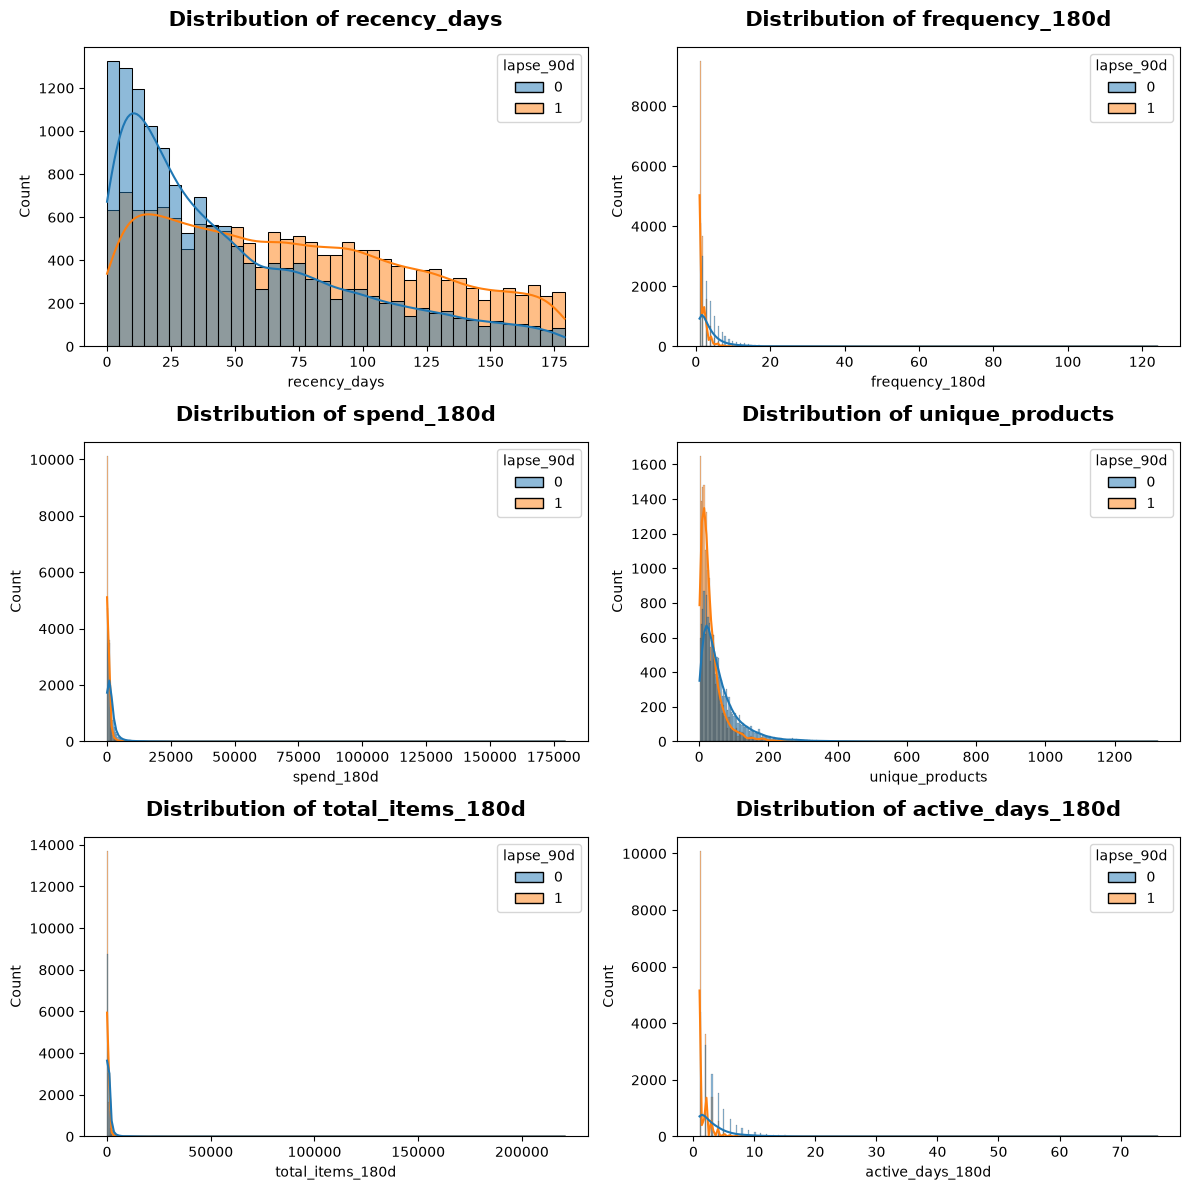

In [38]:
# Visualize numerical columns
fig1, axes1 = plt.subplots(3, 2, figsize=(12, 12))

axes1 = axes1.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(data=train_data, x=col, hue='lapse_90d', kde=True, ax=axes1[i])
    axes1[i].set_title(f'Distribution of {col}', pad=15, weight='bold', fontsize=15)

plt.tight_layout()
plt.show()

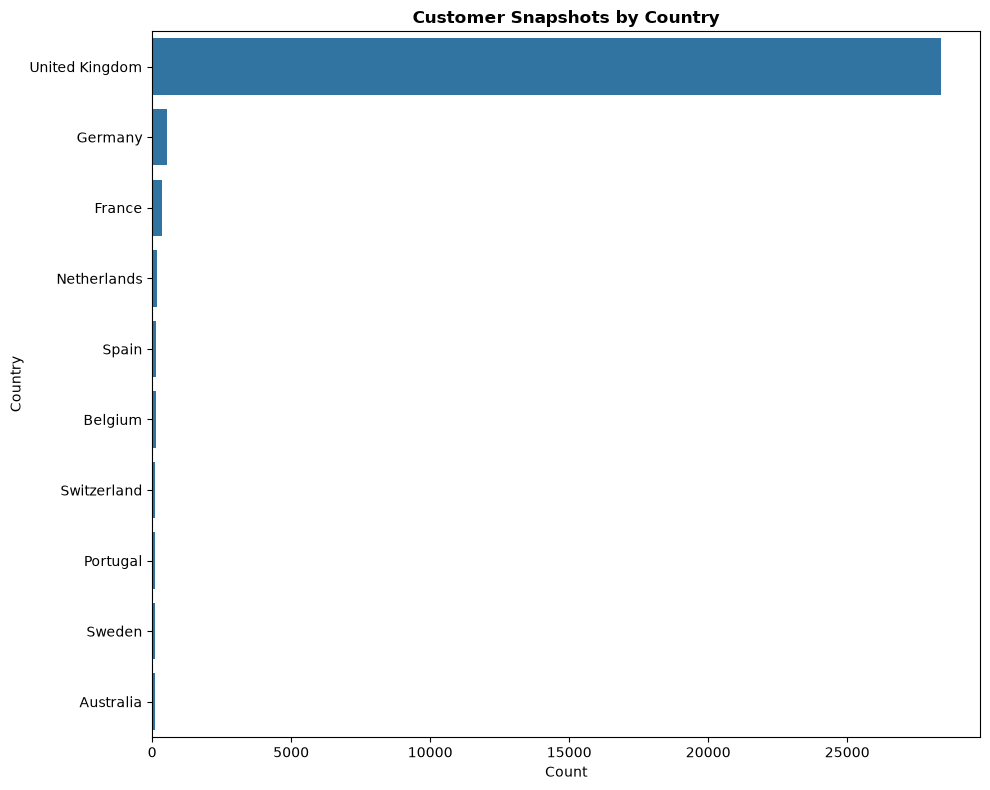

In [56]:
# Distribution of countries
country_counts = train_data['country'].value_counts().head(10)

plt.figure(figsize=(10, 8))
sns.barplot(
    x=country_counts.values,
    y=country_counts.index
)

plt.title('Customer Snapshots by Country', weight='bold')
plt.xlabel('Count')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [55]:
by_country = train_data.groupby("country")["customer_id"].nunique().sort_values(ascending=False)
pd.DataFrame({"customers": by_country, "share": by_country / by_country.sum()}).head(10).round(3)

,customers,share
country,,
United Kingdom,4150,0.917
Germany,75,0.017
France,55,0.012
Spain,27,0.006
Netherlands,22,0.005
Belgium,20,0.004
Portugal,18,0.004
Sweden,16,0.004
Switzerland,15,0.003


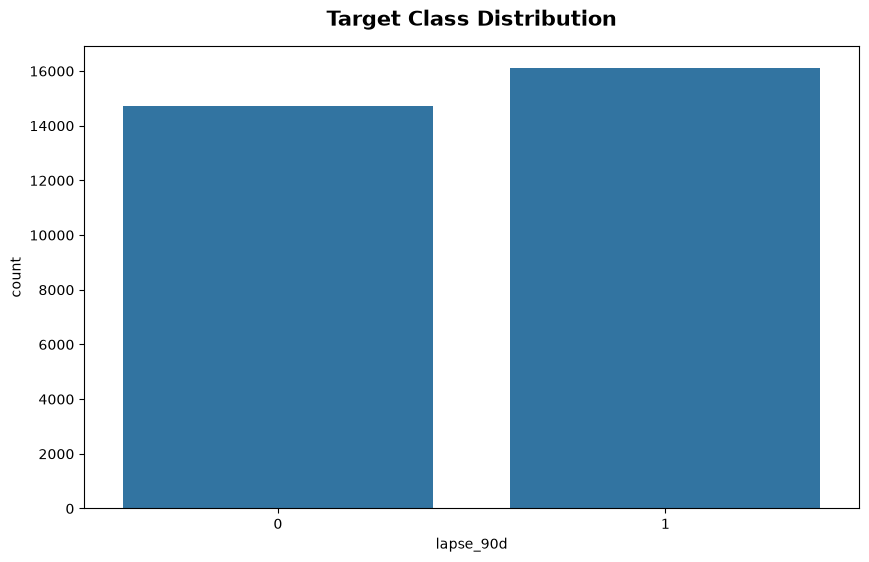

In [40]:
# Target class distribution
plt.figure(figsize=(10,6))
sns.countplot(x='lapse_90d', data=train_data)
plt.title('Target Class Distribution', pad=15, fontsize=15, weight='bold')
plt.show()

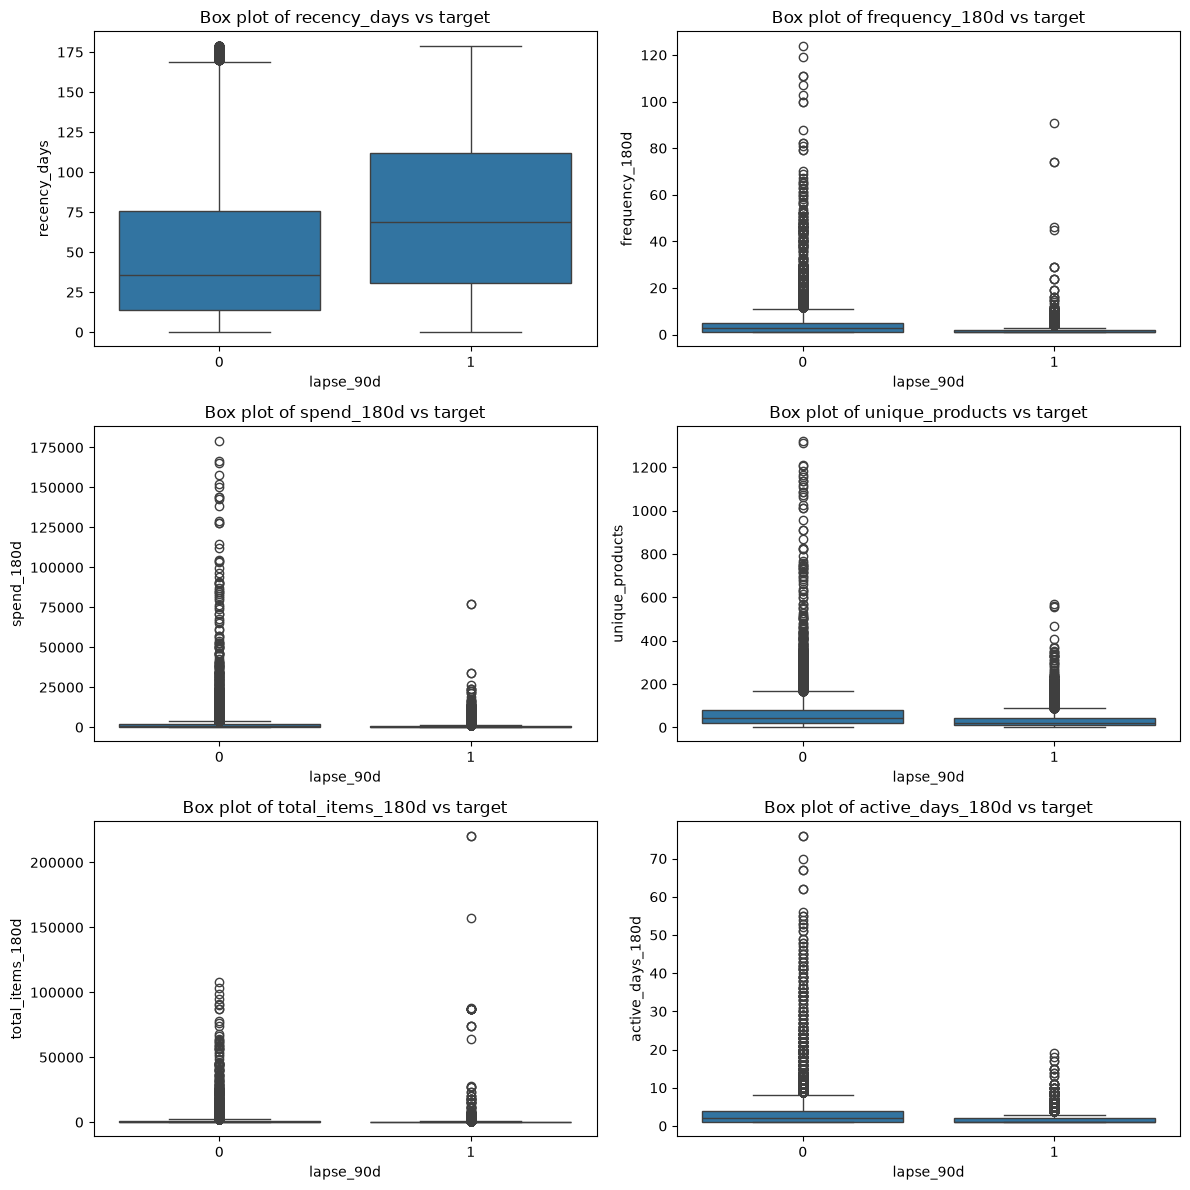

In [41]:
# Box plots
fig2, axes2 = plt.subplots(3, 2, figsize=(12, 12))
axes2 = axes2.flatten()

for j, col in enumerate(num_cols):
  sns.boxplot(x='lapse_90d', y=col, data=train_data, ax=axes2[j])
  axes2[j].set_title(f"Box plot of {col} vs target")

plt.tight_layout()
plt.show()

<Axes: >

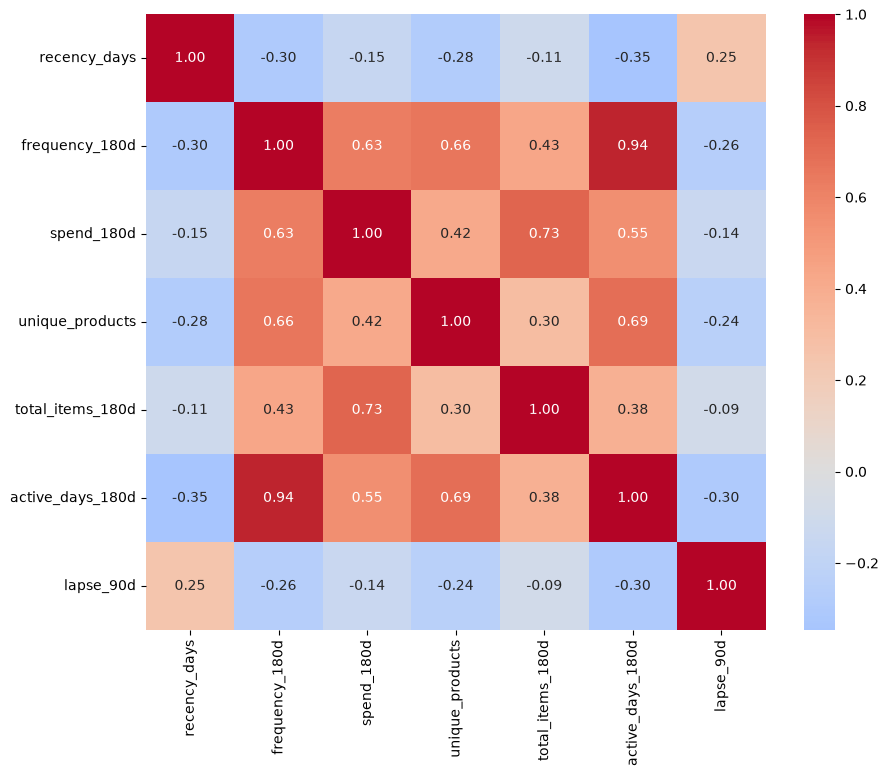

In [42]:
# Correlation between columns
corr_cols = [
    'recency_days',
    'frequency_180d',
    'spend_180d',
    'unique_products',
    'total_items_180d',
    'active_days_180d',
    'lapse_90d'
]

corr_matrix = train_data[corr_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

# 5. Preprocessing & Feature Engineering



In [48]:
train_data.head()

,customer_id,reference_date,lapse_90d,recency_days,frequency_180d,spend_180d,unique_products,total_items_180d,active_days_180d,country
0,12779.0,2010-06-01,0,91,2,690.68,35,460,2,Poland
1,13611.0,2010-06-01,0,53,3,781.87,54,421,3,United Kingdom
2,15255.0,2010-06-01,0,179,1,260.44,13,176,1,United Kingdom
3,14771.0,2010-06-01,1,64,2,594.62,46,622,2,United Kingdom
4,14838.0,2010-06-01,1,179,1,119.10,4,18,1,United Kingdom


## 5.1 Feature Engineering

In [67]:
def engineer_features(df):
    df = df.copy()

    df['avg_order_value_180d'] = (
        df['spend_180d'] / df['frequency_180d']
    )

    df['avg_items_per_order_180d'] = (
        df['total_items_180d'] / df['frequency_180d']
    )

    df['avg_spend_per_active_day'] = (
        df['spend_180d'] / df['active_days_180d']
    )

    df['products_per_order'] = (
        df['unique_products'] / df['frequency_180d']
    )

    df['items_per_active_day'] = (
        df['total_items_180d'] / df['active_days_180d']
    )

    df['is_single_order'] = (
        df['frequency_180d'] == 1
    ).astype(int)

    # Country feature
    df['is_uk'] = (
        df['country'] == 'United Kingdom'
    ).astype(int)

    df = df.drop(columns=['customer_id', 'reference_date', 'country'])

    return df

In [68]:
train_data = engineer_features(train_data)
val_data = engineer_features(val_data)
test_data = engineer_features(test_data)

train_data.head()

,lapse_90d,recency_days,frequency_180d,spend_180d,unique_products,total_items_180d,active_days_180d,avg_order_value_180d,avg_items_per_order_180d,avg_spend_per_active_day,products_per_order,items_per_active_day,is_single_order,is_uk
0,0,91,2,690.68,35,460,2,345.340000,230.000000,345.340000,17.5,230.000000,0,0
1,0,53,3,781.87,54,421,3,260.623333,140.333333,260.623333,18.0,140.333333,0,1
2,0,179,1,260.44,13,176,1,260.440000,176.000000,260.440000,13.0,176.000000,1,1
3,1,64,2,594.62,46,622,2,297.310000,311.000000,297.310000,23.0,311.000000,0,1
4,1,179,1,119.10,4,18,1,119.100000,18.000000,119.100000,4.0,18.000000,1,1


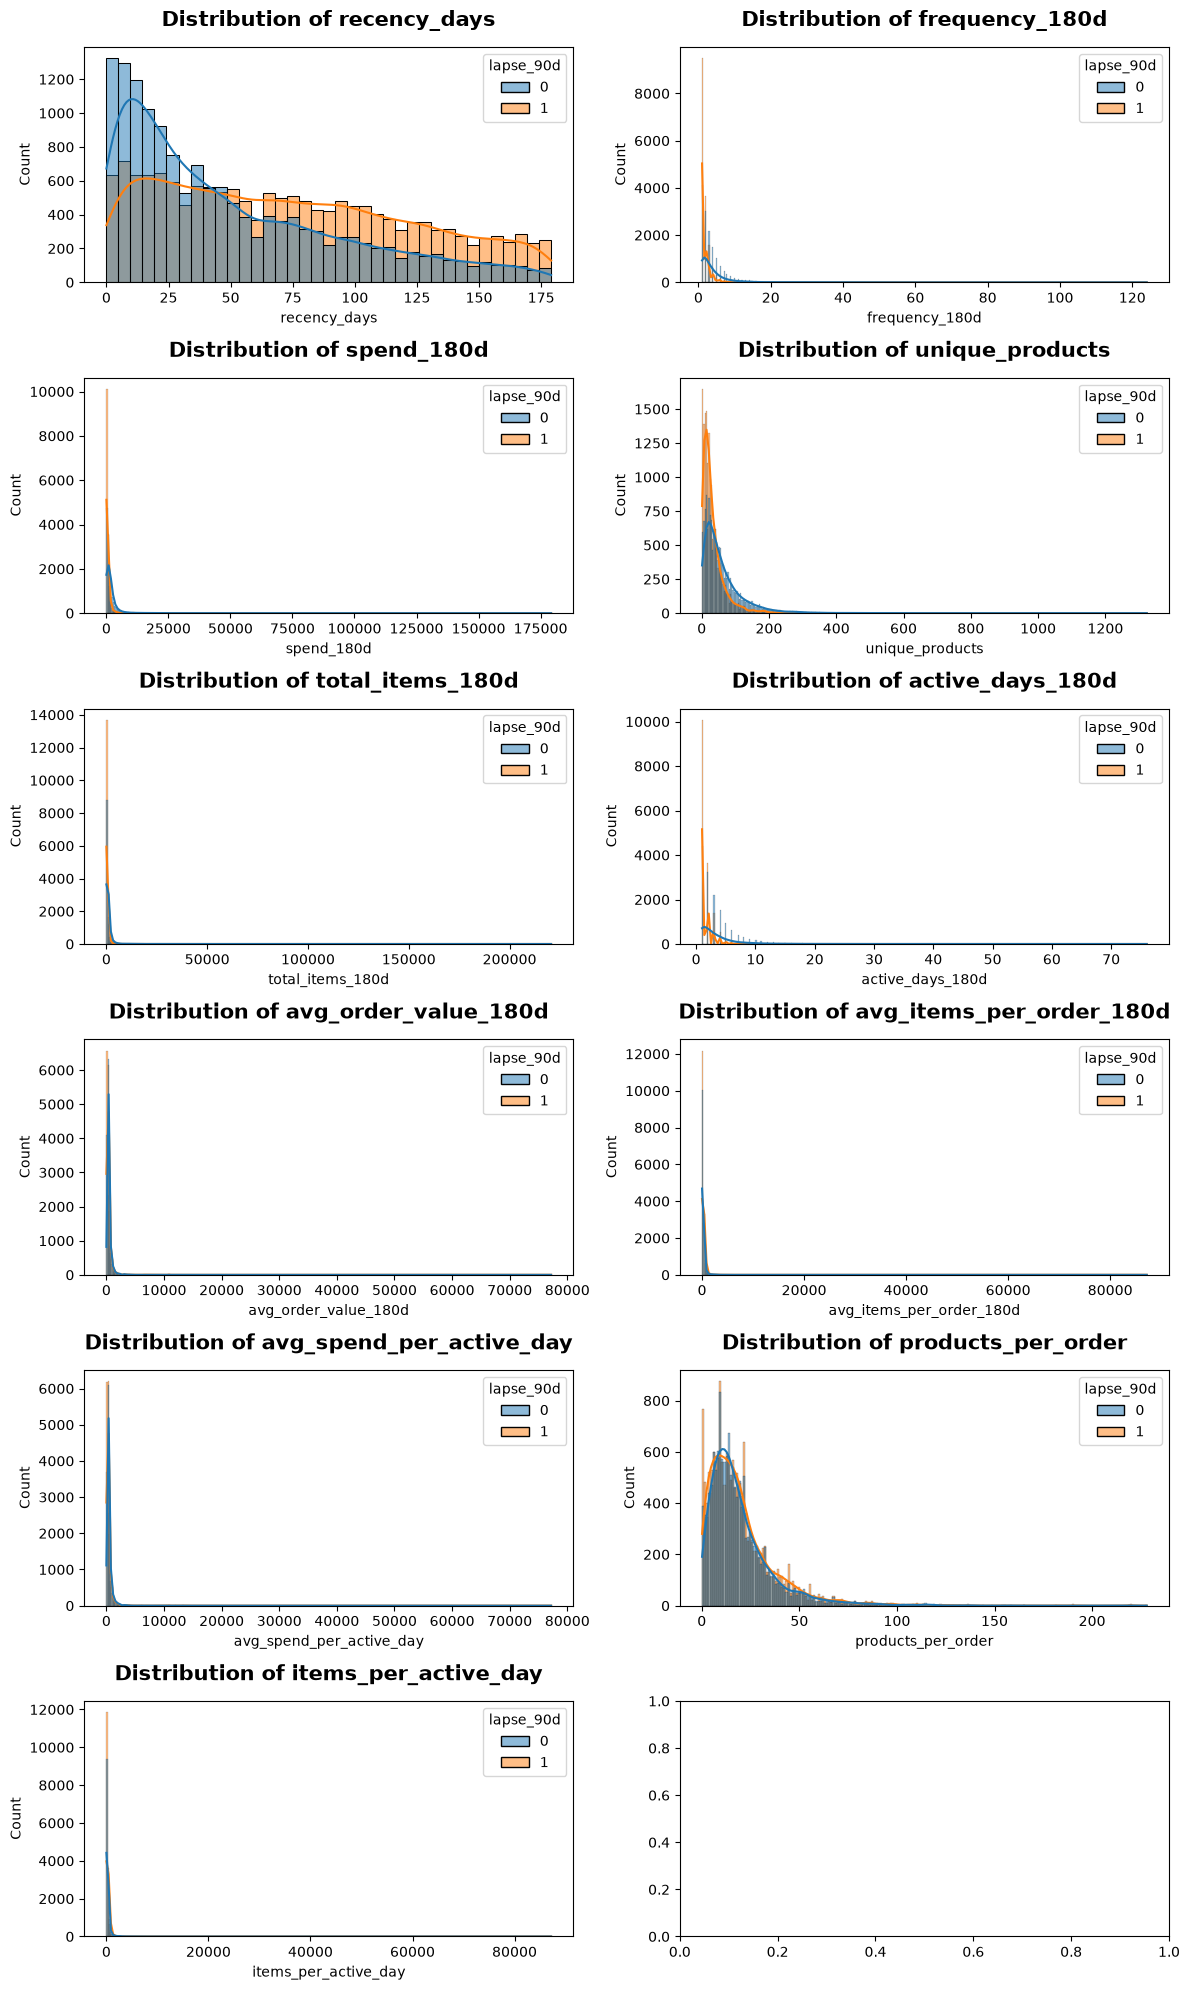

In [69]:
# Visualize numerical columns
fig1, axes1 = plt.subplots(6, 2, figsize=(12, 20))

axes1 = axes1.flatten()
numeric_cols = ['recency_days', 'frequency_180d', 'spend_180d', 'unique_products', 'total_items_180d', 'active_days_180d', 'avg_order_value_180d', 'avg_items_per_order_180d', 'avg_spend_per_active_day', 'products_per_order', 'items_per_active_day']

for i, col in enumerate(numeric_cols):
    sns.histplot(data=train_data, x=col, hue='lapse_90d', kde=True, ax=axes1[i])
    axes1[i].set_title(f'Distribution of {col}', pad=15, weight='bold', fontsize=15)

plt.tight_layout()
plt.show()

In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

log_cols = [
    'frequency_180d',
    'spend_180d',
    'unique_products',
    'total_items_180d',
    'active_days_180d',
    'avg_order_value_180d',
    'avg_items_per_order_180d',
    'avg_spend_per_active_day',
    'products_per_order',
    'items_per_active_day'
]

passthrough_cols = [
    'recency_days',
    'is_single_order'
]

log_pipeline = Pipeline([
    ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('log_features', log_pipeline, log_cols),
    ('other_features', StandardScaler(), passthrough_cols)
])

# 6. Model Development

*To be completed next.*


# 7. Model Evaluation, Optimization & Ethics

*To be completed after model development.*


# 8. Impact Reporting (Stakeholder-Facing)

*To be completed after final model selection.*
